# Auto Email / Ticket Categorizer

AI/ML Intern Assessment - Fobes Skill Itech

Author: Aayush Saini

Goal: Build a simple NLP model that reads a support ticket (subject + body) and
predicts which department it should go to - Billing, Technical, HR or General.

Dataset used here is a small dummy dataset I created myself for this assessment
(see `data/build_dataset.py`). No real/public dataset has been used.

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## 1. Load the dataset

In [2]:
df = pd.read_csv("data/tickets.csv")
print("Total tickets:", len(df))
df["category"].value_counts()

Total tickets: 80


category
Billing      20
Technical    20
HR           20
General      20
Name: count, dtype: int64

In [3]:
df.head()

,ticket_id,subject,body,category
0,TCK-1000,Invoice not received,I made the payment last week but I still have ...,Billing
1,TCK-1001,Wrong amount charged,My card was charged 1500 rupees but my plan co...,Billing
2,TCK-1002,Refund delayed,I cancelled my subscription 10 days back and w...,Billing
3,TCK-1003,Subscription renewed without confirmation,My yearly plan got renewed automatically and m...,Billing
4,TCK-1004,Payment failed but amount deducted,"I tried to pay for the premium plan, the payme...",Billing


## 2. Clean the text

Combined subject and body into one text field, then did basic cleaning:
- lowercase everything
- removed punctuation and numbers
- removed common stopwords (using a small custom list instead of downloading nltk data)

In [4]:
STOPWORDS = set("""
a an the is are was were am be been being to of in on for and or but if
this that these those i you he she it we they my your his her its our
their me him them us not no do does did doing have has had having
please can could will would should also just about with as at by from
""".split())

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()
    words = [w for w in words if w not in STOPWORDS and len(w) > 1]
    return " ".join(words)

df["text"] = df["subject"] + " " + df["body"]
df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text"]].head()

,text,clean_text
0,Invoice not received I made the payment last w...,invoice received made payment last week still ...
1,Wrong amount charged My card was charged 1500 ...,wrong amount charged card charged rupees plan ...
2,Refund delayed I cancelled my subscription 10 ...,refund delayed cancelled subscription days bac...
3,Subscription renewed without confirmation My y...,subscription renewed without confirmation year...
4,Payment failed but amount deducted I tried to ...,payment failed amount deducted tried pay premi...


## 3. Train/test split and TF-IDF features

Used TF-IDF instead of plain bag-of-words / word counts because it reduces the
weight of words that appear in almost every ticket (like "please", "issue") and
gives more importance to words that are actually useful for telling categories apart.

In [5]:
X = df["clean_text"]
y = df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Train size:", X_train_tfidf.shape)
print("Test size:", X_test_tfidf.shape)

Train size: (64, 409)
Test size: (16, 409)


## 4. Train the model

Went with Multinomial Naive Bayes since it's a standard baseline for text
classification tasks and works reasonably well even on a small dataset like this one.

In [6]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)
print("Model trained.")

Model trained.


## 5. Evaluate the model

In [7]:
y_pred = model.predict(X_test_tfidf)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 3))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.938

              precision    recall  f1-score   support

     Billing       1.00      1.00      1.00         4
     General       0.80      1.00      0.89         4
          HR       1.00      0.75      0.86         4
   Technical       1.00      1.00      1.00         4

    accuracy                           0.94        16
   macro avg       0.95      0.94      0.94        16
weighted avg       0.95      0.94      0.94        16



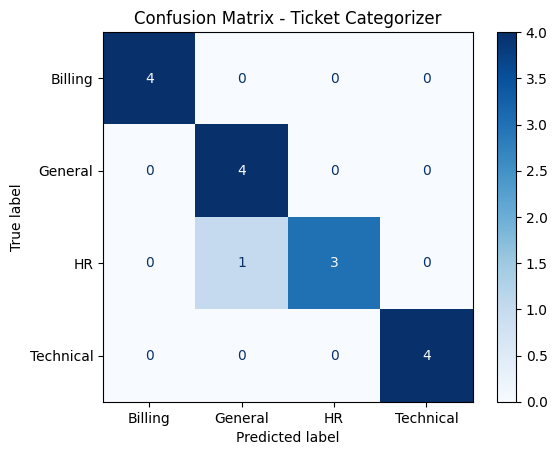

In [8]:
labels = sorted(df["category"].unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Ticket Categorizer")
plt.show()

## 6. Predict on new sample tickets

These 5 tickets are written by me and were never part of the training data.

In [9]:
URGENT_WORDS = ["down", "urgent", "not working", "asap", "immediately", "crash", "failed", "broken", "error"]

def get_priority(text):
    text_lower = text.lower()
    for word in URGENT_WORDS:
        if word in text_lower:
            return "Urgent"
    return "Normal"

def predict_tickets(ticket_texts, confidence_threshold=60):
    results = []
    for ticket in ticket_texts:
        cleaned = clean_text(ticket)
        vec = vectorizer.transform([cleaned])
        probs = model.predict_proba(vec)[0]
        classes = model.classes_
        best_idx = probs.argmax()

        category = classes[best_idx]
        confidence = round(probs[best_idx] * 100, 1)
        status = "Auto-assigned" if confidence >= confidence_threshold else "Needs human review"
        priority = get_priority(ticket)

        results.append({
            "ticket": ticket,
            "category": category,
            "confidence": confidence,
            "status": status,
            "priority": priority,
        })
    return results

new_tickets = [
    "I was charged twice for my monthly subscription, please refund one of the charges",
    "The app keeps crashing every time I try to upload a photo, please help",
    "Can you tell me my remaining leave balance for this quarter",
    "What is the difference between your basic and premium plans",
    "Server is down and none of my api requests are working, this is urgent",
]

results = predict_tickets(new_tickets)
pd.DataFrame(results)

,ticket,category,confidence,status,priority
0,I was charged twice for my monthly subscriptio...,Billing,45.0,Needs human review,Normal
1,The app keeps crashing every time I try to upl...,Technical,49.1,Needs human review,Urgent
2,Can you tell me my remaining leave balance for...,HR,35.7,Needs human review,Normal
3,What is the difference between your basic and ...,General,29.7,Needs human review,Normal
4,Server is down and none of my api requests are...,Technical,32.4,Needs human review,Urgent


## 7. Reflection

- Accuracy on the test set came out quite high, but the test set is very small (only
  16 tickets) since the whole dataset is just 80 rows, so this number should not be
  taken too seriously.
- Confidence scores on the new sample tickets are on the lower side even when the
  predicted category is correct. This is common with Naive Bayes on small datasets -
  it still picks the right class but is not very "sure" about it.
- With more data (a few hundred real tickets per category) the model would likely
  give higher and more reliable confidence scores, and I would also like to try
  Logistic Regression and compare it with Naive Bayes on the same data.
- Right now the "needs human review" threshold is a fixed 60%, with more time this
  could be tuned properly using a validation set instead of picking it manually.